In [1]:
# Initialize data and imports

#System
import os, random, sys, itertools

#Data manipulation and entry
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import numpy as np
import h5py

## ML packages
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim




plt.rcParams['text.usetex'] = False

psi = np.load('/home/fabio/work/HM_and_AI_models/VAE_Model/data/long_run_310k.npy')

psi = psi[:,1,:]

# Normalization
mean_psi = np.mean(psi, axis=0, keepdims=True)
std_psi = np.std(psi, axis=0, keepdims=True)
psi = (psi - mean_psi) / std_psi

# Pre-processing

lead = 1
trainN = 250000
valN = 50000
index = 63

# Defining the variable ranges
variable_range = [(0,24), (25, 49), (50, 74), (0, 49), (0,74)]

# Select the variable: 0 for real perturbation, 1 for imaginary perturbation, 2 for zonal winds
variable = 3
num_variables = variable_range[variable][1] - variable_range[variable][0] + 1

# Shuffle and map indices
np.random.seed(42)
valid_indices = np.arange(0, trainN - lead)
shuffled_indices = np.random.permutation(valid_indices)

# Now constrain the shuffled indices to the variable range
np_psi_train_input = psi[shuffled_indices, variable_range[variable][0]:variable_range[variable][1]+1]
np_psi_train_label = psi[shuffled_indices + lead, :]

psi_train_input = torch.tensor(np_psi_train_input)
psi_train_label = torch.tensor(np_psi_train_label)

np_psi_val_input = psi[trainN:trainN+valN, variable_range[variable][0]:variable_range[variable][1]+1]
np_psi_val_label = psi[trainN+lead:trainN+valN+lead, :]
psi_val_input = torch.tensor(np_psi_val_input)
psi_val_label =  torch.tensor(np_psi_val_label)


In [2]:
# Define the Model
class Encoder(nn.Module):
    def __init__(self, latent_dim, num_neurons):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(75, num_neurons)  # Input layer (2 + 2) -> Hidden layer (128)
        self.fc2 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc3 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc4 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc5 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc6 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc_mu = nn.Linear(num_neurons, latent_dim)  # Hidden layer (128) -> Latent space (2)
        self.fc_logvar = nn.Linear(num_neurons, latent_dim)  # Hidden layer (128) -> Log variance (2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # Activation function for hidden layer
        x = torch.relu(self.fc2(x)) + x
        x = torch.relu(self.fc3(x)) + x
        x = torch.relu(self.fc4(x)) + x
        x = torch.relu(self.fc5(x)) + x
        x = torch.relu(self.fc6(x)) + x
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

# Define the decoder (MLP)
class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim, condition_dim, num_neurons):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim + condition_dim, num_neurons)  # Input layer (2 + 2) -> Hidden layer (128)
        self.fc2 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc3 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc4 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc5 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc6 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (128) -> Hidden layer (128)
        self.fc_output = nn.Linear(num_neurons, output_dim)  # Hidden layer (128) -> Output layer (2)

    def forward(self, z, condition):
        z = torch.cat((z, condition), dim=1)  # Concatenate latent vector and condition
        z = torch.relu(self.fc1(z))  # Activation function for hidden layer
        z = torch.relu(self.fc2(z)) + z
        z = torch.relu(self.fc3(z)) + z
        z = torch.relu(self.fc4(z)) + z
        z = torch.relu(self.fc5(z)) + z
        z = torch.relu(self.fc6(z)) + z
        output = self.fc_output(z)
        return output

# Define the VAE model
class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim, output_dim, condition_dim, num_neurons):
        super(ConditionalVAE, self).__init__()
        self.encoder = Encoder(latent_dim, num_neurons)
        self.decoder = Decoder(latent_dim, output_dim, condition_dim, num_neurons)

    def encode(self, x):
        mu, logvar = self.encoder(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z, condition):
        return self.decoder(z, condition)

    def forward(self, x, condition):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        output = self.decode(z, condition)
        return output, mu, logvar

output_dim = 75
latent_dim = 32
condition_dim = num_variables
batch_size = 1024

In [3]:
# Load model, and prep data
real_data       = np.load('/home/fabio/work/HM_and_AI_models/VAE_Model/data/long_run_310k.npy')
save_dir        = "/home/fabio/work/HM_and_AI_models/VAE_Model/data/plots_paper"

num_samples     = 1000
level           = 63
start, end      = (0, 50)

latent_dim      = 32
output_dim      = 75
condition_dim   = 50
num_neurons     = 1024

model_path      = "/home/fabio/work/HM_and_AI_models/VAE_Model/data/best_weights/checkpoint_11" 

model           = ConditionalVAE(latent_dim, output_dim, condition_dim, num_neurons).cuda()
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, weights_only=True))
    print("Model loaded Sucessfully!")

Model loaded Sucessfully!


SSW Transitions A to B: 199, Mean: 18.12
SSW Transitions B to A: 199, Mean: 7.97
Equilibrium Points A: 199, Mean: 22.98
Equilibrium Points B: 199, Mean: 1.77

Randomly sampled indices: AB=38, BA=253, A=580, B=787
Total number of initial conditions: 796

Running 1000 inference runs...


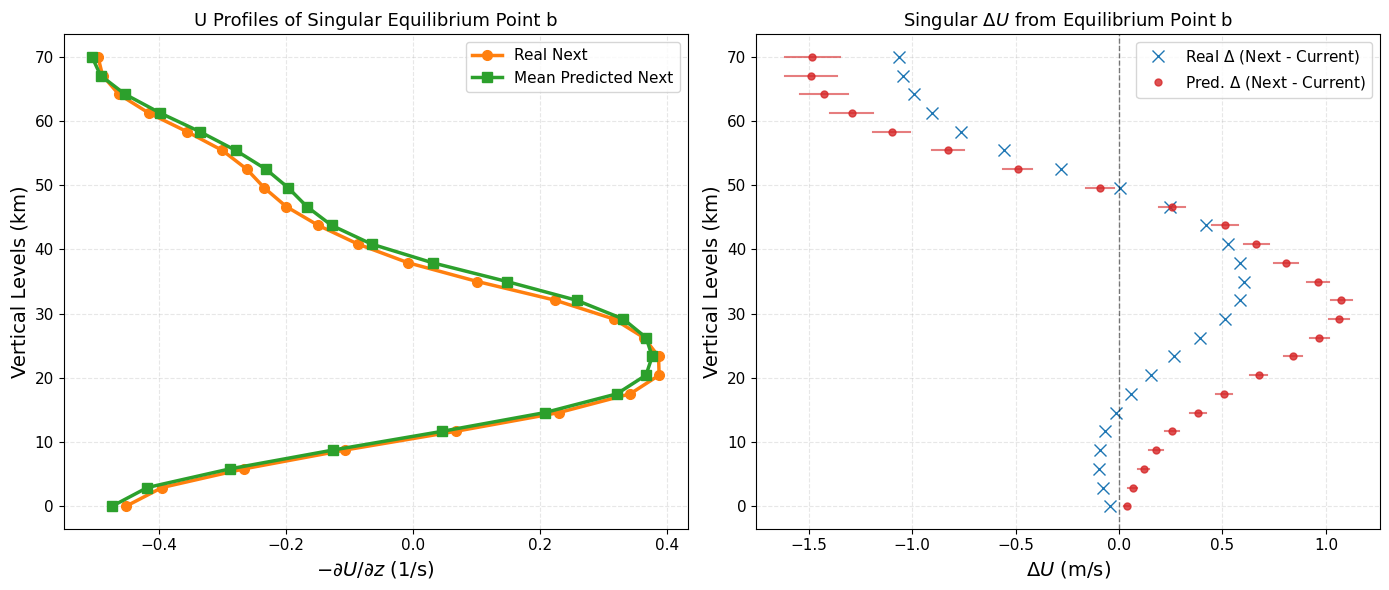


Analysis Summary
Type: Equilibrium Point b
IC Index: 787
Number of ensemble members: 1000
Mean prediction RMSE: 0.3604 m/s
Max absolute error: 0.5771 m/s


In [4]:
# Single time step analysis
# ============================================================================
# DISABLE LaTeX (fixes the rendering error)
# ============================================================================
plt.rcParams['text.usetex'] = False

# ============================================================================
# STEP 1: Define thresholds and detect transitions
# ============================================================================
upper_bound = 53.8 / 2.8935
lower_bound = 7.41
zonal_wind = real_data[:, 1, 63]
timesteps = 1000

def detect_transitions_A_to_B(u_series, upper, lower):
    """Detect transitions from Set A (high values) to Set B (low values)"""
    transitions = []
    transition_values = []
    i = 0
    while i < len(u_series) - 1:
        if u_series[i-1] > upper and u_series[i] <= upper:
            j = i + 1
            while j < len(u_series) and u_series[j] <= upper:
                if u_series[j] < lower:
                    transitions.append(i)
                    transition_values.append(u_series[i])
                    break
                j += 1
            i = j
        else:
            i += 1
    return np.array(transitions), np.array(transition_values)

def detect_transitions_B_to_A(u_series, upper, lower):
    """Detect transitions from Set B (low values) to Set A (high values)"""
    transitions = []
    transition_values = []
    i = 0
    while i < len(u_series) - 1:
        if u_series[i-1] < lower and u_series[i] >= lower:
            j = i + 1
            while j < len(u_series) and u_series[j] >= lower:
                if u_series[j] > upper:
                    transitions.append(i)
                    transition_values.append(u_series[i])
                    break
                j += 1
            i = j
        else:
            i += 1
    return np.array(transitions), np.array(transition_values)

# ============================================================================
# STEP 2: Identify transition and equilibrium points
# ============================================================================
ssw_indices_A1, ssw_transition_values_A1 = detect_transitions_A_to_B(
    real_data[:, 1, 63], upper_bound, lower_bound
)
ssw_indices_B1, ssw_transition_values_B1 = detect_transitions_B_to_A(
    real_data[:, 1, 63], upper_bound, lower_bound
)

# Find non-transition equilibrium points
transition_indices = np.union1d(ssw_indices_A1, ssw_indices_B1)
total_len = len(real_data)
non_ssw_indices_A1 = np.where(
    (real_data[:, 1, 63] > upper_bound) & 
    (~np.isin(np.arange(total_len), transition_indices))
)[0]
non_ssw_indices_B1 = np.where(
    (real_data[:, 1, 63] < lower_bound) & 
    (~np.isin(np.arange(total_len), transition_indices))
)[0]

# Balance the dataset
n_samples = min(
    len(ssw_indices_A1), 
    len(ssw_indices_B1), 
    len(non_ssw_indices_A1), 
    len(non_ssw_indices_B1)
)

non_ssw_indices_A1 = np.random.choice(non_ssw_indices_A1, size=n_samples, replace=False)
non_ssw_indices_B1 = np.random.choice(non_ssw_indices_B1, size=n_samples, replace=False)
non_ssw_transition_values_A1 = zonal_wind[non_ssw_indices_A1]
non_ssw_transition_values_B1 = zonal_wind[non_ssw_indices_B1]

print(f"SSW Transitions A to B: {len(ssw_indices_A1)}, Mean: {np.mean(ssw_transition_values_A1):.2f}")
print(f"SSW Transitions B to A: {len(ssw_indices_B1)}, Mean: {np.mean(ssw_transition_values_B1):.2f}")
print(f"Equilibrium Points A: {len(non_ssw_indices_A1)}, Mean: {np.mean(non_ssw_transition_values_A1):.2f}")
print(f"Equilibrium Points B: {len(non_ssw_indices_B1)}, Mean: {np.mean(non_ssw_transition_values_B1):.2f}")

# ============================================================================
# STEP 3: Select one random initial condition from each category
# ============================================================================

time_indices_AB = random.sample(range(0, n_samples - 1), 1)[0]
time_indices_BA = random.sample(range(n_samples, n_samples * 2 - 1), 1)[0]
time_indices_A = random.sample(range(n_samples * 2, n_samples * 3 - 1), 1)[0]
time_indices_B = random.sample(range(n_samples * 3, n_samples * 4 - 1), 1)[0]

print(f"\nRandomly sampled indices: AB={time_indices_AB}, BA={time_indices_BA}, A={time_indices_A}, B={time_indices_B}")
selected_ics = [time_indices_AB, time_indices_BA, time_indices_A, time_indices_B]

# ============================================================================
# STEP 4: Prepare data for model inference
# ============================================================================
# Combine all initial conditions
ics = np.concatenate([
    ssw_indices_A1, 
    ssw_indices_B1, 
    non_ssw_indices_A1, 
    non_ssw_indices_B1
])
next_time_step = ics + 1

# Extract current and next states
real_current = real_data[ics, 1, :]
real_next = real_data[next_time_step, 1, :]

num_of_ics = len(ics)
print(f"Total number of initial conditions: {num_of_ics}")

# Prepare input for VAE
X = np.vstack([
    real_data[ssw_indices_A1, 1],
    real_data[ssw_indices_B1, 1],
    real_data[non_ssw_indices_A1, 1],
    real_data[non_ssw_indices_B1, 1],
]).astype(np.float32)

X = (X - mean_psi) / std_psi
X = X[:, :50]  # Use only first 50 components as input

# ============================================================================
# STEP 5: Run VAE inference (generate predictions)
# ============================================================================
initial_cond = torch.reshape(torch.tensor(X), [num_of_ics, num_variables])
z = torch.zeros([num_of_ics, latent_dim])
save = np.zeros([timesteps, num_of_ics, 75])

print(f"\nRunning {timesteps} inference runs...")
for j in range(timesteps):
    with torch.no_grad():
        z = torch.randn_like(z)  # Sample from latent space
        y = model.decode(z.float().cuda(), initial_cond.float().cuda())
        y = y.detach().cpu().numpy()
    save[j, :, :] = y

# Denormalize predictions
pred_next_denorm = save * std_psi.squeeze() + mean_psi.squeeze()

# ============================================================================
# STEP 6: Extract zonal wind profiles
# ============================================================================
U_current_real = real_current[:, 50:75]  # Shape: (num_of_ics, 25)
U_next_real = real_next[:, 50:75]        # Shape: (num_of_ics, 25)
U_next_pred = pred_next_denorm[:, :, 50:75]  # Shape: (timesteps, num_of_ics, 25)

# Define labels for each type of initial condition
types_of_ics = [
    "Transition Point from Set A to Set B", 
    "Transition Point from Set B to Set A", 
    "Equilibrium Point a", 
    "Equilibrium Point b"
]

# ============================================================================
# STEP 7: Analyze a specific initial condition
# ============================================================================
selected_ic_index = 3 # 0=AB, 1=BA, 2=Point a, 3=Point b
selected_ic = selected_ics[selected_ic_index]

# Extract data for the selected IC
U_current_single = U_current_real[selected_ic, :]  # Shape: (25,)
U_next_real_single = U_next_real[selected_ic, :]  # Shape: (25,)
U_next_pred_single = U_next_pred[:, selected_ic, :]  # Shape: (timesteps, 25)

# Calculate statistics across ensemble predictions
U_mean_pred = np.mean(U_next_pred_single, axis=0)  # Shape: (25,)
U_std_pred = np.std(U_next_pred_single, axis=0)    # Shape: (25,)

# Calculate deltas (changes from current to next)
delta_U_real = U_next_real_single - U_current_single  # Real change
delta_U_pred_all = U_next_pred_single - U_current_single  # All predicted changes
mean_delta_U = np.mean(delta_U_pred_all, axis=0)  # Mean predicted change
std_delta_U = np.std(delta_U_pred_all, axis=0)    # Std of predicted change

# Define vertical levels (0 to ~70 km)
vertical_levels = np.arange(0, 25) * (70 / 24)

# ============================================================================
# STEP 8: Create visualization
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel 1: Slope plot (-dU/dz) ---
ax1 = axes[0]

# Calculate vertical gradient of zonal wind
slopes_real = -np.gradient(U_next_real_single, vertical_levels)
slopes_pred = -np.gradient(U_mean_pred, vertical_levels)

ax1.plot(slopes_real, vertical_levels, 'o-', color='tab:orange', 
         label='Real Next', linewidth=2.5, markersize=7)
ax1.plot(slopes_pred, vertical_levels, 's-', color='tab:green', 
         label='Mean Predicted Next', linewidth=2.5, markersize=7)

ax1.set_xlabel(r'$-\partial U/\partial z$ (1/s)', fontsize=14)
ax1.set_ylabel('Vertical Levels (km)', fontsize=14)
ax1.set_title(f'U Profiles of Singular {types_of_ics[selected_ic_index]}', fontsize=13)
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(labelsize=11)

# --- Panel 2: Delta U plot ---
ax2 = axes[1]

# Plot real change
ax2.plot(delta_U_real, vertical_levels, 'x', color='tab:blue', 
         label=r'Real $\Delta$ (Next - Current)', markersize=8, linewidth=2)

# Plot one predicted change
ax2.plot(mean_delta_U, vertical_levels, 'o', color='tab:red', 
         label=r'Pred. $\Delta$ (Next - Current)', markersize=5, alpha=0.8)

# Plot uncertainty bounds (mean ± 2σ)
for i in range(len(vertical_levels)):
    lower = mean_delta_U[i] - 2 * std_delta_U[i]
    upper = mean_delta_U[i] + 2 * std_delta_U[i]
    ax2.plot([lower, upper], [vertical_levels[i], vertical_levels[i]], 
             color='tab:red', linewidth=1.5, alpha=0.6)

# Add reference line at zero
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

ax2.set_xlabel(r'$\Delta U$ (m/s)', fontsize=14)
ax2.set_ylabel('Vertical Levels (km)', fontsize=14)
ax2.set_title(f'Singular $\\Delta U$ from {types_of_ics[selected_ic_index]}', fontsize=13)
ax2.legend(fontsize=11, loc='best')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

# ============================================================================
# STEP 9: Print diagnostic information
# ============================================================================
print(f"\n{'='*60}")
print(f"Analysis Summary")
print(f"{'='*60}")
print(f"Type: {types_of_ics[selected_ic_index]}")
print(f"IC Index: {selected_ic}")
print(f"Number of ensemble members: {timesteps}")
print(f"Mean prediction RMSE: {np.sqrt(np.mean((U_mean_pred - U_next_real_single)**2)):.4f} m/s")
print(f"Max absolute error: {np.max(np.abs(U_mean_pred - U_next_real_single)):.4f} m/s")
print(f"{'='*60}")

Configuration:
  Model Step Size: 1 Day
  Forecast Horizon: 400 Days
  Averaging 80 Initial Conditions


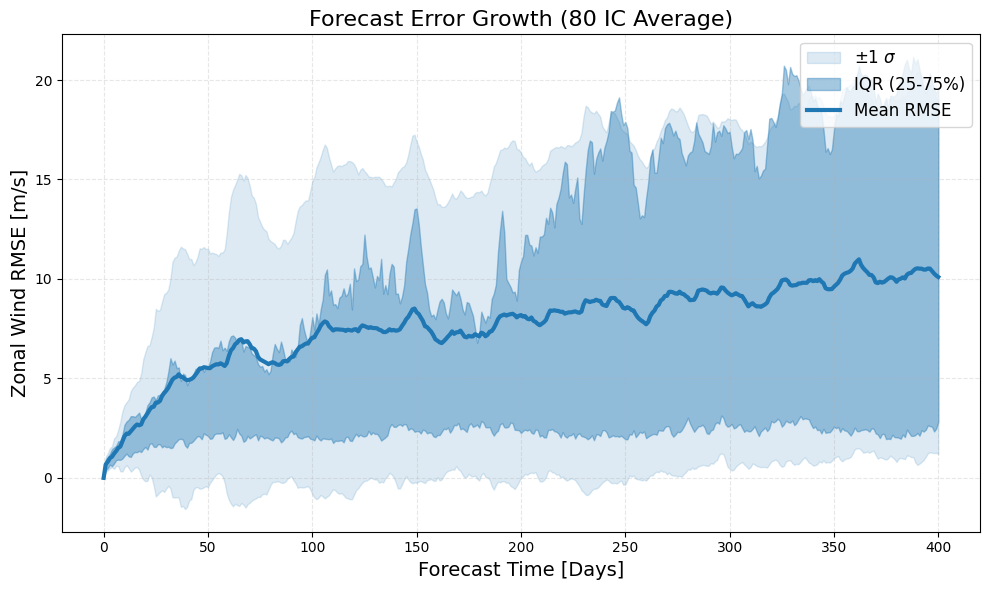

In [10]:
# ============================================================================
# 1. Forecast Function (1 Step = 1 Day)
# ============================================================================
def run_iterative_forecast(model, initial_cond_50, num_days, num_ensemble=50):
    """
    Parameters:
    - initial_cond_50: The starting state (Day 0), sliced to first 50 vars.
    - num_days: Number of days to forecast.
    """
    # Output shape: (num_days, num_ensemble, 75)
    predictions = np.zeros([num_days, num_ensemble, 75])
    
    current_cond = initial_cond_50.clone()
    
    for day in range(num_days):
        with torch.no_grad():
            z = torch.randn(num_ensemble, latent_dim).cuda()
            current_cond_expanded = current_cond.repeat(num_ensemble, 1).cuda()
            
            # Decode: Input (z + cond) -> Output (Next Day's Full State)
            y = model.decode(z.float(), current_cond_expanded.float())
            y_np = y.detach().cpu().numpy()
            
            predictions[day, :, :] = y_np
            
            # RECURSION STEP:
            # The model output (y) is the state for Day T+1.
            # We take the mean of the ensemble to be the input for Day T+2.
            # CRITICAL: Slice to [:50] because the encoder only takes 50 inputs.
            mean_pred = np.mean(y_np, axis=0, keepdims=True)
            current_cond = torch.tensor(mean_pred[:, :50]).float()
            
    return predictions

# ============================================================================
# 2. Configuration
# ============================================================================
# Load data
real_data = np.load('/home/fabio/work/HM_and_AI_models/VAE_Model/data/long_run_310k.npy')

# Physical Time Parameters
dt_physical = 1.0          # Data is already 1 day per index
num_forecast_days = 400 # Forecast 200 days out
num_ensemble = 50 # Ensemble members per IC
num_ics_to_average = 80 # Number of curves to average
condition_dim = 50         # Model input size

# Calculate valid sampling range
# We need contiguous data for the length of the forecast
max_valid_idx = real_data.shape[0] - num_forecast_days - 1
selected_ic_indices = np.random.choice(max_valid_idx, num_ics_to_average, replace=False)

print(f"Configuration:")
print(f"  Model Step Size: 1 Day")
print(f"  Forecast Horizon: {num_forecast_days} Days")
print(f"  Averaging {num_ics_to_average} Initial Conditions")

# ============================================================================
# 3. Main Loop
# ============================================================================
all_rmse_curves = []

for i, idx in enumerate(selected_ic_indices):
    if i % 10 == 0: print(f"Processing IC {i}/{num_ics_to_average}...", end='\r')

    # --- A. Prepare Initial Condition (Day 0) ---
    # Grab Day 0, normalize, and slice to 50 variables for the model input
    raw_ic = real_data[idx:idx+1, :] 
    ic_norm = (raw_ic - mean_psi) / std_psi 
    initial_cond_50 = torch.tensor(ic_norm[:, 1, :condition_dim]).float() 
    
    # --- B. Get Ground Truth (Day 1 to Day 200) ---
    # Since data is 1-day steps, we just slice directly
    ground_truth = real_data[idx+1 : idx + num_forecast_days + 1, 1, 50:75]

    # --- C. Run Forecast ---
    # Returns (200, ensemble, 75)
    preds_norm = run_iterative_forecast(model, initial_cond_50, num_forecast_days, num_ensemble)
    
    # --- D. Denormalize ---
    preds_phys = preds_norm * std_psi.squeeze() + mean_psi.squeeze()
    preds_phys_zonal = preds_phys[:, :, 50:75] 

    # --- E. Add Day 0 for Visualization ---
    # Get Day 0 Truth (the IC)
    ic_phys = real_data[idx:idx+1, 1, 50:75]
    
    # Expand IC for ensemble and concatenate
    ic_expanded = np.repeat(ic_phys[np.newaxis, :, :], num_ensemble, axis=1)
    preds_full = np.concatenate([ic_expanded, preds_phys_zonal], axis=0)
    
    # Add Day 0 to Ground Truth
    ground_truth_full = np.concatenate([ic_phys, ground_truth], axis=0)

    # --- F. Calculate RMSE ---
    # Mean over ensemble members
    preds_mean = np.mean(preds_full, axis=1)
    
    # Difference vs Truth
    diff = preds_mean - ground_truth_full
    
    # RMS over the 25 spatial variables (Zonal Wind)
    rmse_t = np.sqrt(np.mean(diff**2, axis=1))
    all_rmse_curves.append(rmse_t)

# ============================================================================
# 4. Plotting
# ============================================================================
all_rmse_curves = np.array(all_rmse_curves)

# Basic stats
mean_rmse = np.mean(all_rmse_curves, axis=0)
std_rmse = np.std(all_rmse_curves, axis=0)

# Calculate IQR (25th and 75th percentiles) across the ensemble/IC axis (axis 0)
rmse_q25 = np.percentile(all_rmse_curves, 25, axis=0)
rmse_q75 = np.percentile(all_rmse_curves, 75, axis=0)

# Time axis is simply days
time_days = np.arange(len(mean_rmse))

plt.figure(figsize=(10, 6))

# 1. Plot Standard Deviation (Lighter, wider spread)
plt.fill_between(time_days, mean_rmse - std_rmse, mean_rmse + std_rmse, 
                 color='tab:blue', alpha=0.15, label='±1 $\sigma$')

# 2. Plot IQR (Darker, inner spread)
plt.fill_between(time_days, rmse_q25, rmse_q75, 
                 color='tab:blue', alpha=0.4, label='IQR (25-75%)')

# 3. Plot Mean
plt.plot(time_days, mean_rmse, color='tab:blue', linewidth=3, label='Mean RMSE')

plt.xlabel('Forecast Time [Days]', fontsize=14)
plt.ylabel('Zonal Wind RMSE [m/s]', fontsize=14)
plt.title(f'Forecast Error Growth ({num_ics_to_average} IC Average)', fontsize=16)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig(f"{save_dir}/rmse_forecast_days_iqr.png")
plt.show()